# Imports

In [1]:
import os
import numpy as np
from tqdm.notebook import tqdm
from scipy.signal import resample
import xml.etree.ElementTree as ET
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Input, Dense, LSTM
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from matplotlib import pyplot as plt
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd

# Constants

In [2]:
NUM_POINTS = 50

NOTEBOOK_DIR = os.path.abspath('')
TRAIN_DIR = os.path.join(NOTEBOOK_DIR, "..", "logs")
TEST_DIR = os.path.join(NOTEBOOK_DIR, "..", "datasets")

# Load data

In [3]:
# diclaimer: this function was coded with the help of AI
def load_xml_samples(root_dir):
    data = []
    for root, subdirs, files in os.walk(root_dir):
        if 'ipynb_checkpoint' in root:
            continue
        xml_files = [f for f in files if f.endswith('.xml')]
        if not xml_files:
            continue
        for f in tqdm(xml_files, desc=root):
            fname = f.split('.')[0]
            label = fname.rstrip('0123456789')  # strip trailing digits (rep number)

            xml_root = ET.parse(os.path.join(root, f)).getroot()

            points = []
            for element in xml_root.findall('Point'):
                x = element.get('X')
                y = element.get('Y')
                points.append([x, y])

            points = np.array(points, dtype=float)

            scaler = StandardScaler()
            points = scaler.fit_transform(points)

            resampled = resample(points, NUM_POINTS)

            data.append((label, resampled))
    return data

In [4]:

train_data = load_xml_samples(TRAIN_DIR)
test_data = load_xml_samples(TEST_DIR)

print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")
print(f"Training classes: {sorted(set(label for label, _ in train_data))}")
print(f"Test classes: {sorted(set(label for label, _ in test_data))}")

c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-06-gesture-recognition-martinarobyculas…

c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-06-gesture-recognition-martinarobyculas…

c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-06-gesture-recognition-martinarobyculas…

c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-06-gesture-recognition-martinarobyculas…

c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-06-gesture-recognition-martinarobyculas…

...

c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-06-gesture-recognition-martinarobyculas…

c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-06-gesture-recognition-martinarobyculas…

c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-06-gesture-recognition-martinarobyculas…

c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-06-gesture-recognition-martinarobyculas…

Training samples: 5280
Test samples: 160
Training classes: ['arrow', 'caret', 'check', 'circle', 'delete_mark', 'left_curly_brace', 'left_sq_bracket', 'pigtail', 'question_mark', 'rectangle', 'right_curly_brace', 'right_sq_bracket', 'star', 'triangle', 'v', 'x']
Test classes: ['arrow', 'caret', 'check', 'circle', 'delete_mark', 'left_curly_brace', 'left_sq_bracket', 'pigtail', 'question_mark', 'rectangle', 'right_curly_brace', 'right_sq_bracket', 'star', 'triangle', 'v', 'x']


In [5]:
data = []

for root, subdirs, files in os.walk('../logs'):
    if 'ipynb_checkpoint' in root:
        continue
    
    if len(files) > 0:
        for f in tqdm(files):
            if '.xml' in f:
                fname = f.split('.')[0]
                label = fname[:-2]
                
                xml_root = ET.parse(f'{root}/{f}').getroot()
                
                points = []
                for element in xml_root.findall('Point'):
                    x = element.get('X')
                    y = element.get('Y')
                    points.append([x, y])
                    
                points = np.array(points, dtype=float)
                
                scaler = StandardScaler()
                points = scaler.fit_transform(points)
                
                resampled = resample(points, NUM_POINTS)
                
                data.append((label, resampled))

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

...

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

In [6]:
test_data = []

for root, subdirs, files in os.walk('../datasets'):
    if 'ipynb_checkpoint' in root:
        continue
    
    if len(files) > 0:
        for f in tqdm(files):
            if '.xml' in f:
                fname = f.split('.')[0]
                label = fname[:-2]
                
                xml_root = ET.parse(f'{root}/{f}').getroot()
                
                points = []
                for element in xml_root.findall('Point'):
                    x = element.get('X')
                    y = element.get('Y')
                    points.append([x, y])
                    
                points = np.array(points, dtype=float)
                
                scaler = StandardScaler()
                points = scaler.fit_transform(points)
                
                resampled = resample(points, NUM_POINTS)
                
                test_data.append((label, resampled))

  0%|          | 0/161 [00:00<?, ?it/s]

# Prepare data

In [7]:
# prepare the data
labels = [sample[0] for sample in data]
print("labels: ", set(labels))

# encode (make string-labels numerical)
encoder = LabelEncoder()
labels_encoded = encoder.fit_transform(labels)
print("encoded: ", set(labels_encoded))

# get labels of data
y = to_categorical(labels_encoded)
print("num labels (encoded): ", len(y[0]))

# get point sequences of data
sequences = [sample[1] for sample in data]
X = np.array(sequences)

# split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

labels:  {'v', 'question_mark', 'x', 'left_sq_bracket', 'right_sq_bracket', 'arrow', 'pigtail', 'circle', 'rectangle', 'check', 'delete_mark', 'right_curly_brace', 'triangle', 'caret', 'star', 'left_curly_brace'}
encoded:  {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)}
num labels (encoded):  16
(4224, 50, 2) (1056, 50, 2) (4224, 16) (1056, 16)


In [8]:
# prepare my own captured data as the final test set (separate from Wobbrock's data)
test_labels = [sample[0] for sample in test_data]
test_labels_encoded = encoder.transform(test_labels)
y_test = to_categorical(test_labels_encoded, num_classes=len(encoder.classes_))

test_sequences = [sample[1] for sample in test_data]
X_test = np.array(test_sequences)

print(X_test.shape, y_test.shape)

(160, 50, 2) (160, 16)


# Models

## Definition

### Extra Large

In [34]:
model_xlarge = Sequential()

model_xlarge.add(Input((NUM_POINTS, 2)))
model_xlarge.add(LSTM(128))
model_xlarge.add(Dense(64, activation='relu'))
model_xlarge.add(Dense(len(set(labels)), activation='softmax'))

model_xlarge.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_xlarge.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 128)            │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,368 (298.31 KB)

 Trainable params: 76,368 (298.31 KB)

 Non-trainable params: 0 (0.00 B)

### Large
Baseline model, demo notebook from GRIPS

In [35]:
model_large = Sequential()

# add LSTM layer
# input shape is (length of an individual sample, dimensions of the sample)
# in our case: two dimensions, as we have X and Y coordinates

model_large.add(Input((NUM_POINTS, 2)))
model_large.add(LSTM(64))

# add dense layer to do machine learning magic
model_large.add(Dense(32, activation='relu'))

# softmax layer for classification
model_large.add(Dense(len(set(labels)), activation='softmax'))

# Compile the model
model_large.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_large.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,760 (77.19 KB)

 Trainable params: 19,760 (77.19 KB)

 Non-trainable params: 0 (0.00 B)

### Medium

In [36]:
model_medium = Sequential()

model_medium.add(Input((NUM_POINTS, 2)))
model_medium.add(LSTM(32))
model_medium.add(Dense(16, activation='relu'))
model_medium.add(Dense(len(set(labels)), activation='softmax'))

model_medium.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_medium.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 32)             │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           272 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,280 (20.62 KB)

 Trainable params: 5,280 (20.62 KB)

 Non-trainable params: 0 (0.00 B)

### Small

In [37]:
model_small = Sequential()

model_small.add(Input((NUM_POINTS, 2)))
model_small.add(LSTM(16))
model_small.add(Dense(8, activation='relu'))
model_small.add(Dense(len(set(labels)), activation='softmax'))

model_small.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_small.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 16)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │           144 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,496 (5.84 KB)

 Trainable params: 1,496 (5.84 KB)

 Non-trainable params: 0 (0.00 B)

### Extra Small

In [38]:
model_xsmall = Sequential()

model_xsmall.add(Input((NUM_POINTS, 2)))
model_xsmall.add(LSTM(8))
model_xsmall.add(Dense(4, activation='relu'))
model_xsmall.add(Dense(len(set(labels)), activation='softmax'))

model_xsmall.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_xsmall.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 8)              │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │            80 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468 (1.83 KB)

 Trainable params: 468 (1.83 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [39]:
# callbacks
def fresh_callbacks():
    return [
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001, verbose=1),
        EarlyStopping(monitor='val_loss', patience=3, verbose=1),
    ]

### Extra Large

In [40]:
# train the xlarge model
history_xlarge = model_xlarge.fit(
    X_train,
    y_train,
    epochs=12,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=fresh_callbacks()
)

Epoch 1/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6979 - loss: 0.9227 - val_accuracy: 0.9176 - val_loss: 0.2357 - learning_rate: 0.0010
Epoch 2/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9489 - loss: 0.1562 - val_accuracy: 0.9062 - val_loss: 0.3085 - learning_rate: 0.0010
Epoch 3/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9768 - loss: 0.0865 - val_accuracy: 0.9593 - val_loss: 0.1366 - learning_rate: 0.0010
Epoch 4/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9841 - loss: 0.0599 - val_accuracy: 0.9839 - val_loss: 0.0543 - learning_rate: 0.0010
Epoch 5/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9747 - loss: 0.0818 - val_accuracy: 0.9811 - val_loss: 0.0598 - learning_rate: 0.0010
Epoch 6/12
130/132 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9830 - loss: 0.0521
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9825 - loss: 0.

### Large

In [41]:
# train the large model
history_large = model_large.fit(
    X_train,
    y_train,
    epochs=12,  #10
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=fresh_callbacks()
)

Epoch 1/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5703 - loss: 1.6244 - val_accuracy: 0.8144 - val_loss: 0.6665 - learning_rate: 0.0010
Epoch 2/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9164 - loss: 0.3286 - val_accuracy: 0.9498 - val_loss: 0.1844 - learning_rate: 0.0010
Epoch 3/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9659 - loss: 0.1302 - val_accuracy: 0.9678 - val_loss: 0.1123 - learning_rate: 0.0010
Epoch 4/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9834 - loss: 0.0702 - val_accuracy: 0.9801 - val_loss: 0.0703 - learning_rate: 0.0010
Epoch 5/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9806 - loss: 0.0701 - val_accuracy: 0.9858 - val_loss: 0.0524 - learning_rate: 0.0010
Epoch 6/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9882 - loss: 0.0513 - val_accuracy: 0.9886 - val_loss: 0.0447 - learning_rate: 0.0010
Epoch 7/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9865 - loss: 0.

### Medium

In [42]:
# train the medium model
history_medium = model_medium.fit(
    X_train,
    y_train,
    epochs=12,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=fresh_callbacks()
)

Epoch 1/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3364 - loss: 2.1293 - val_accuracy: 0.6714 - val_loss: 1.2350 - learning_rate: 0.0010
Epoch 2/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8622 - loss: 0.6868 - val_accuracy: 0.9148 - val_loss: 0.3967 - learning_rate: 0.0010
Epoch 3/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9467 - loss: 0.2642 - val_accuracy: 0.9347 - val_loss: 0.2866 - learning_rate: 0.0010
Epoch 4/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9695 - loss: 0.1508 - val_accuracy: 0.9792 - val_loss: 0.1090 - learning_rate: 0.0010
Epoch 5/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9825 - loss: 0.0971 - val_accuracy: 0.9830 - val_loss: 0.0724 - learning_rate: 0.0010
Epoch 6/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9841 - loss: 0.0731 - val_accuracy: 0.9886 - val_loss: 0.0579 - learning_rate: 0.0010
Epoch 7/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9886 - loss: 0.

### Small

In [43]:
# train the small model
history_small = model_small.fit(
    X_train,
    y_train,
    epochs=12,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=fresh_callbacks()
)

Epoch 1/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.2363 - loss: 2.4840 - val_accuracy: 0.3523 - val_loss: 2.0779 - learning_rate: 0.0010
Epoch 2/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4422 - loss: 1.6853 - val_accuracy: 0.6070 - val_loss: 1.3135 - learning_rate: 0.0010
Epoch 3/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6828 - loss: 1.0766 - val_accuracy: 0.7850 - val_loss: 0.8334 - learning_rate: 0.0010
Epoch 4/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8184 - loss: 0.7043 - val_accuracy: 0.8390 - val_loss: 0.5786 - learning_rate: 0.0010
Epoch 5/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8608 - loss: 0.4979 - val_accuracy: 0.8684 - val_loss: 0.4249 - learning_rate: 0.0010
Epoch 6/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9006 - loss: 0.3791 - val_accuracy: 0.8949 - val_loss: 0.3437 - learning_rate: 0.0010
Epoch 7/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9252 - loss: 0.2

### Extra Small

In [44]:
# train the xsmall model
history_xsmall = model_xsmall.fit(
    X_train,
    y_train,
    epochs=12,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=fresh_callbacks()
)

Epoch 1/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.1560 - loss: 2.6390 - val_accuracy: 0.2225 - val_loss: 2.4969 - learning_rate: 0.0010
Epoch 2/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2493 - loss: 2.3620 - val_accuracy: 0.3116 - val_loss: 2.1780 - learning_rate: 0.0010
Epoch 3/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3286 - loss: 2.0349 - val_accuracy: 0.3939 - val_loss: 1.8794 - learning_rate: 0.0010
Epoch 4/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4252 - loss: 1.7820 - val_accuracy: 0.4886 - val_loss: 1.6726 - learning_rate: 0.0010
Epoch 5/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4690 - loss: 1.6011 - val_accuracy: 0.5019 - val_loss: 1.5187 - learning_rate: 0.0010
Epoch 6/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5166 - loss: 1.4574 - val_accuracy: 0.5644 - val_loss: 1.3928 - learning_rate: 0.0010
Epoch 7/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5784 - loss: 1.3397

### Training curves

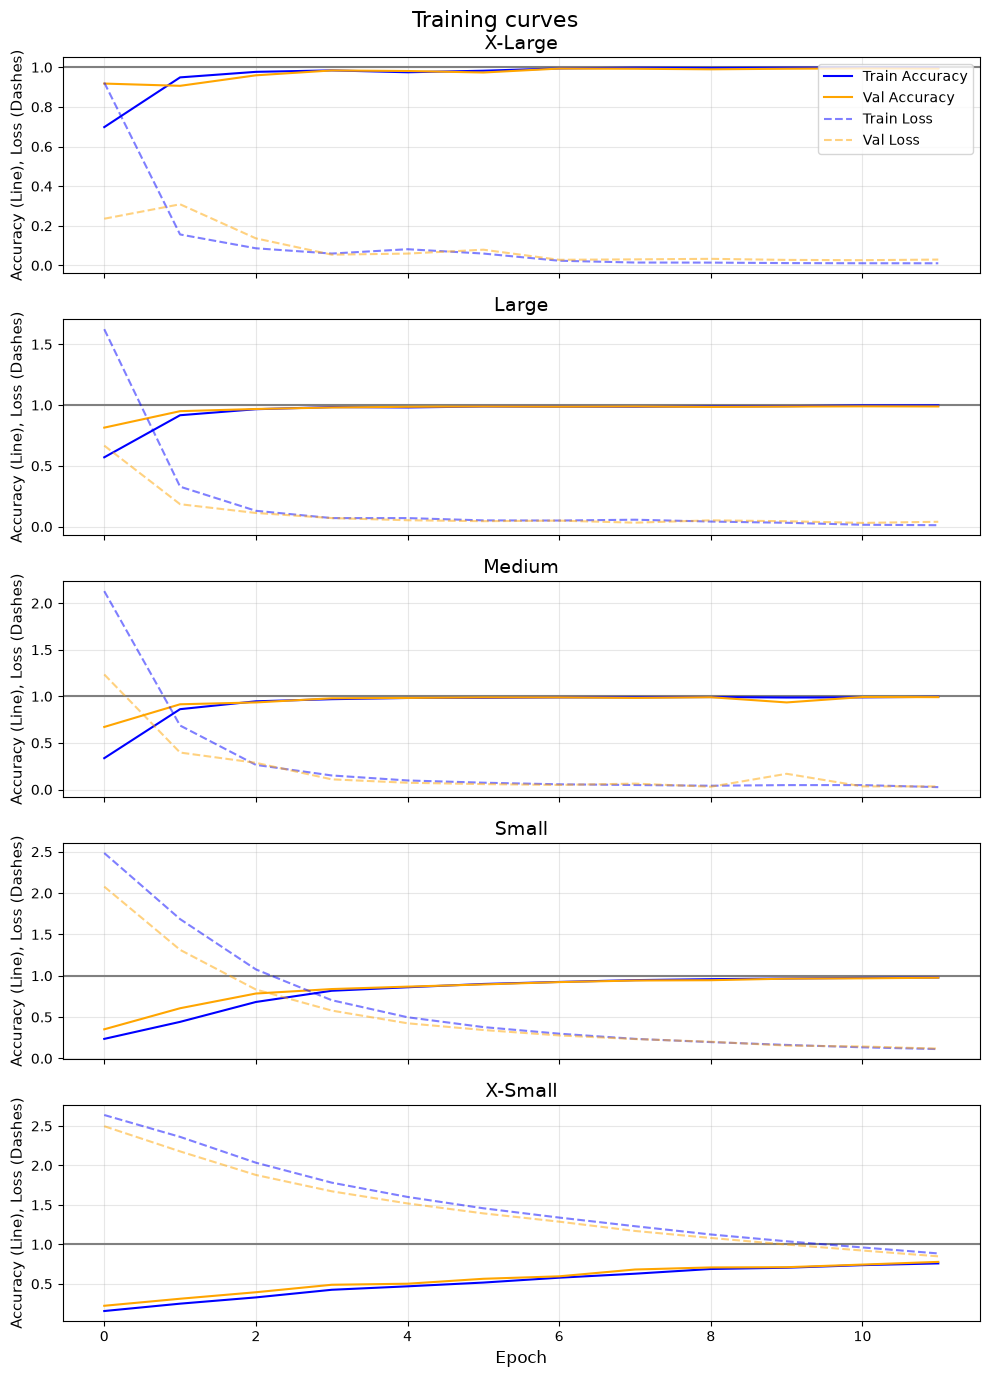

In [45]:
models_info = [('X-Large', history_xlarge), ('Large', history_large), ('Medium', history_medium), ('Small', history_small), ('X-Small', history_xsmall)]

fig, axes = plt.subplots(5, 1, figsize=(10, 14), sharex=True)

for ax, (name, history) in zip(axes, models_info):
    ax.axhline(1, color='gray')
    ax.grid(True, alpha=0.3)
    ax.plot(history.history['accuracy'], color='blue', label='Train Accuracy')
    ax.plot(history.history['val_accuracy'], color='orange', label='Val Accuracy')
    ax.plot(history.history['loss'], '--', color='blue', alpha=0.5, label='Train Loss')
    ax.plot(history.history['val_loss'], '--', color='orange', alpha=0.5, label='Val Loss')
    ax.set_ylabel('Accuracy (Line), Loss (Dashes)', fontsize=11)
    ax.set_title(name, fontsize=14)

axes[0].legend(fontsize=10, loc='upper right')
axes[-1].set_xlabel('Epoch', fontsize=12)
plt.suptitle('Training curves', fontsize=16)
plt.tight_layout()
plt.show()

# Predictions and results
On my own test data

### Extra Large

#### Prediction time

In [46]:
# make predictions for all the samples in test data
t0 = time.time()
predictions_xlarge = model_xlarge.predict(X_test)
t1 = time.time()

prediction_time_xlarge = (t1 - t0) / len(X_test)    # average time per sample
print(f"Average prediction time (large model): {prediction_time_xlarge*1000:.3f} ms/sample")

predicted_labels_xlarge = np.argmax(predictions_xlarge, axis=1)
true_labels_xlarge = np.argmax(y_test, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Average prediction time (large model): 2.616 ms/sample


#### Accuracy

In [47]:
# print accuracy of model on test data
accuracy_xlarge = np.mean(predicted_labels_xlarge == true_labels_xlarge)
print(f"Test accuracy (large model): {accuracy_xlarge:.4f}")

Test accuracy (large model): 0.9563


### Large

#### Prediction time

In [48]:
t0 = time.time()
predictions_large = model_large.predict(X_test)
t1 = time.time()

prediction_time_large = (t1 - t0) / len(X_test)  
print(f"Average prediction time (large model): {prediction_time_large*1000:.3f} ms/sample")

predicted_labels_large = np.argmax(predictions_large, axis=1)
true_labels_large = np.argmax(y_test, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 
Average prediction time (large model): 2.442 ms/sample


#### Accuracy

In [49]:
accuracy_large = np.mean(predicted_labels_large == true_labels_large)
print(f"Test accuracy (large model): {accuracy_large:.4f}")

Test accuracy (large model): 0.9812


### Medium

#### Prediction time

In [50]:
t0 = time.time()
predictions_medium = model_medium.predict(X_test)
t1 = time.time()

prediction_time_medium = (t1 - t0) / len(X_test)  
print(f"Average prediction time (medium model): {prediction_time_medium*1000:.3f} ms/sample")

predicted_labels_medium = np.argmax(predictions_medium, axis=1)
true_labels_medium = np.argmax(y_test, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step 
Average prediction time (medium model): 2.439 ms/sample


#### Accuracy

In [51]:
accuracy_medium = np.mean(predicted_labels_medium == true_labels_medium)
print(f"Test accuracy (medium model): {accuracy_medium:.4f}")

Test accuracy (medium model): 0.9688


### Small

#### Prediction time

In [52]:
t0 = time.time()
predictions_small = model_small.predict(X_test)
t1 = time.time()

prediction_time_small = (t1 - t0) / len(X_test)
print(f"Average prediction time (small model): {prediction_time_small*1000:.3f} ms/sample")

predicted_labels_small = np.argmax(predictions_small, axis=1)
true_labels_small = np.argmax(y_test, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  
Average prediction time (small model): 2.048 ms/sample


#### Accuracy

In [53]:
accuracy_small = np.mean(predicted_labels_small == true_labels_small)
print(f"Test accuracy (small model): {accuracy_small:.4f}")

Test accuracy (small model): 0.9812


### Extra Small

#### Prediction time

In [54]:
t0 = time.time()
predictions_xsmall = model_xsmall.predict(X_test)
t1 = time.time()

prediction_time_xsmall = (t1 - t0) / len(X_test)
print(f"Average prediction time (small model): {prediction_time_xsmall*1000:.3f} ms/sample")

predicted_labels_xsmall = np.argmax(predictions_xsmall, axis=1)
true_labels_xsmall = np.argmax(y_test, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  
Average prediction time (small model): 1.656 ms/sample


#### Accuracy

In [55]:
accuracy_xsmall = np.mean(predicted_labels_xsmall == true_labels_xsmall)
print(f"Test accuracy (small model): {accuracy_xsmall:.4f}")

Test accuracy (small model): 0.7312


### All - Accuracy and Prediction time

In [56]:
comparison = pd.DataFrame({
    'Model': ['X-Large', 'Large', 'Medium', 'Small', 'X-Small'],
    'Parameters': [model_xlarge.count_params(), model_large.count_params(), model_medium.count_params(), model_small.count_params(), model_xsmall.count_params()],
    'Accuracy': [accuracy_xlarge, accuracy_large, accuracy_medium, accuracy_small, accuracy_xsmall],
    'Prediction time (ms/sample)': [prediction_time_xlarge*1000, prediction_time_large*1000, prediction_time_medium*1000, prediction_time_small*1000, prediction_time_xsmall*1000],
})
comparison

,Model,Parameters,Accuracy,Prediction time (ms/sample)
0,X-Large,76368,0.95625,2.615887
1,Large,19760,0.98125,2.442372
2,Medium,5280,0.96875,2.438617
3,Small,1496,0.98125,2.048466
4,X-Small,468,0.73125,1.656415


### All - Confusion matrices

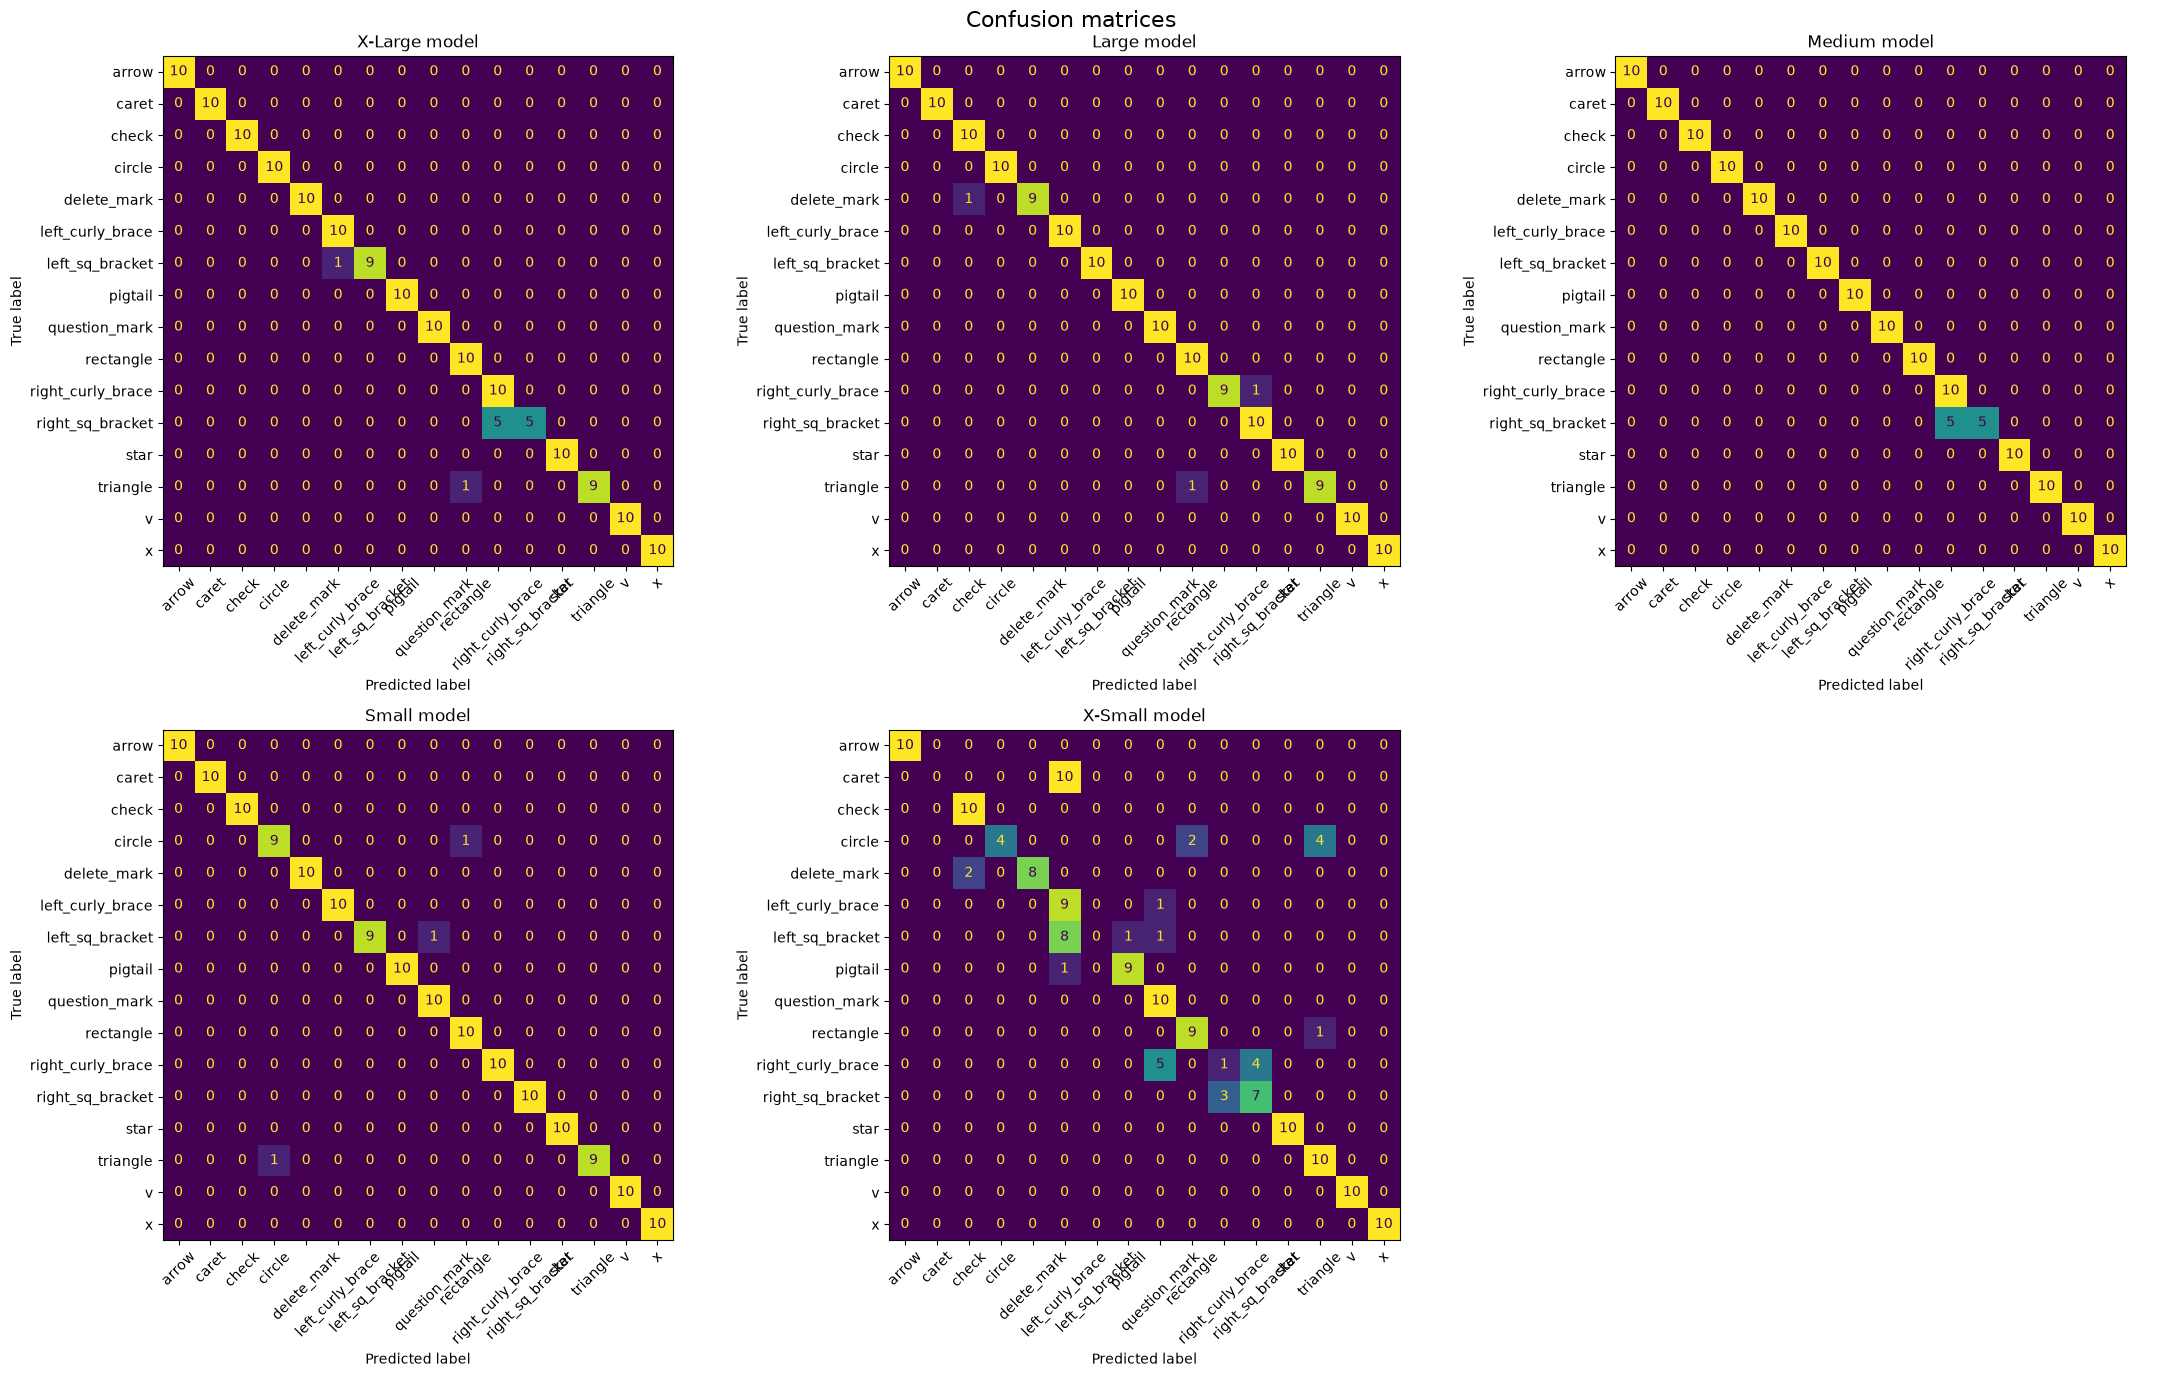

In [57]:
cm_xlarge = confusion_matrix(true_labels_xlarge, predicted_labels_xlarge)
cm_large = confusion_matrix(true_labels_large, predicted_labels_large)
cm_medium = confusion_matrix(true_labels_medium, predicted_labels_medium)
cm_small = confusion_matrix(true_labels_small, predicted_labels_small)
cm_xsmall = confusion_matrix(true_labels_xsmall, predicted_labels_xsmall)

cms_info = [('X-Large', cm_xlarge), ('Large', cm_large), ('Medium', cm_medium), ('Small', cm_small), ('X-Small', cm_xsmall)]

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes = axes.flatten()

for ax, (name, cm) in zip(axes, cms_info):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f'{name} model')

for ax in axes[len(cms_info):]:
    ax.axis('off')

plt.suptitle('Confusion matrices', fontsize=16)
plt.tight_layout()
plt.show()

# Further plots and discussion

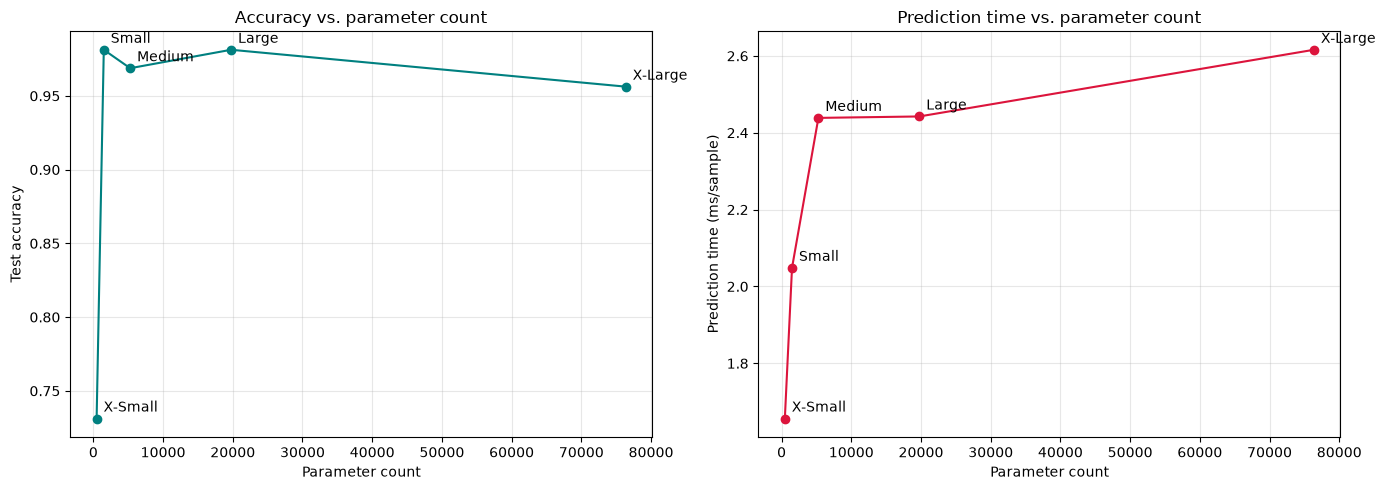

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(comparison['Parameters'], comparison['Accuracy'], 'o-', color='teal')
for x, y, label in zip(comparison['Parameters'], comparison['Accuracy'], comparison['Model']):
    axes[0].annotate(label, (x, y), textcoords='offset points', xytext=(5, 5))
axes[0].set_xlabel('Parameter count'); axes[0].set_ylabel('Test accuracy')
axes[0].set_title('Accuracy vs. parameter count'); axes[0].grid(True, alpha=0.3)

axes[1].plot(comparison['Parameters'], comparison['Prediction time (ms/sample)'], 'o-', color='crimson')
for x, y, label in zip(comparison['Parameters'], comparison['Prediction time (ms/sample)'], comparison['Model']):
    axes[1].annotate(label, (x, y), textcoords='offset points', xytext=(5, 5))
axes[1].set_xlabel('Parameter count'); axes[1].set_ylabel('Prediction time (ms/sample)')
axes[1].set_title('Prediction time vs. parameter count'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Discussion

##### What was done:
- Trained five LSTM configurations (128, 64, 32, 16, and 8 LSTM units, labeled X-Large through X-Small) on the Wobbrock unistroke gesture dataset.
- Applied an 80/20 train/validation split across all 16 gesture classes.
- Evaluated all five final models.
- Compared parameter count, test accuracy, and average prediction time across the five models.

##### What can be seen in the plots:
- Accuracy is not linearly related with parameter count: the Small model almost ties the Large model for the best accuracy, while X-Large actually scores lowest among the four larger configurations.
- Only the X-Small model shows a clear drop in accuracy, the remaining models achieve comparable accuracies.
- Prediction time scales with parameter count.
- X-Large and Medium models share an very similar confusion pattern: right_sq_bracket gets split evenly between the correct class and right_curly_brace. 
- X-Small model shows lots of confusion.

## Which model would I choose for a practical app?

For a practical application I would choose the Small model (16 LSTM units, 1,496 parameters).
- It has the highest test accuracy while using almost 13x fewer parameters than the next highest-scoring model.
- It's also the second-fastest model overall.
- Isolated errors in the confusion matrix.
- Best balance of accuracy, speed, and parameter efficiency, which matters most for a real-time applications.

## Notes: 

- Comparison with $1 Gesture Recognizer missing due to lack of time